In [92]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, f1_score, precision_score, recall_score)
import joblib
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline

In [93]:
# Import Dataset
df = pd.read_csv('online_shoppers_intention.csv')

In [94]:
# Dataset Overview - Shape
df.shape

(12330, 18)

In [95]:
# Dataset Overview - First 5 rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [96]:
# Dataset Overview - Data types, Number of non-null entries, and Memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [97]:
# Dataset Overview - Summary Stats
df.describe(include='all')

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


In [98]:
# EDA & Pre-processing - Check missing values
df.isnull()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12326,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12327,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12328,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [99]:
# EDA & Pre-processing
print(df.isnull().sum()) # Sum of missing values
numeric_cols = df.select_dtypes(include=['number']) # Select numeric coloums
print(numeric_cols.var()) # Check numeric features variance

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64
Administrative             1.103425e+01
Administrative_Duration    3.125085e+04
Informational              1.613297e+00
Informational_Duration     1.981036e+04
ProductRelated             1.978070e+03
ProductRelated_Duration    3.662130e+06
BounceRates                2.351117e-03
ExitRates                  2.361624e-03
PageValues                 3.447868e+02
SpecialDay                 3.956808e-02
OperatingSystems           8.305129e-01
Browser                  

In [100]:
# EDA & Pre-processing - Apply median imputation method on missing values
print(df.isnull().sum())

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [101]:
# EDA & Pre-processing
target_col = 'Revenue' # Assign variable to a target column

num_cols = df.select_dtypes(include=[np.number]).columns.tolist() # List of numeric columns

# Exclude target column from numeric columns
if target_col in num_cols:
    num_cols.remove(target_col)

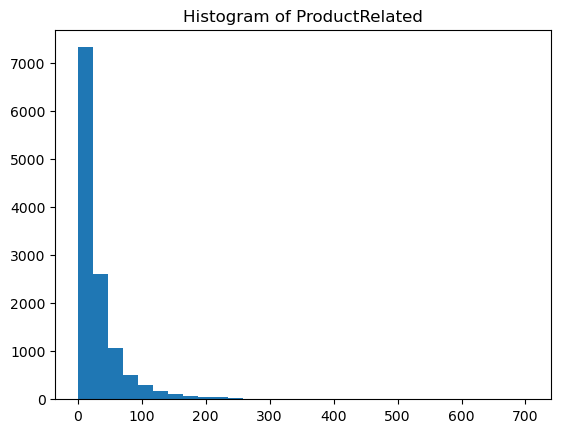

In [102]:
# EDA & Pre-processing - Histogram of Numeric Features - Histogram of ProductRelated
plt.hist(df[num_cols[4]], bins=30)
plt.title(f'Histogram of {num_cols[4]}')
plt.show()

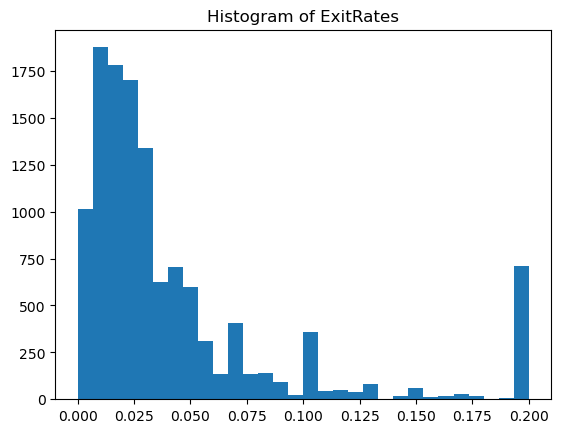

In [103]:
# EDA & Pre-processing - Histogram of Numeric Features - Histogram of ExitRates
plt.hist(df[num_cols[7]], bins=30)
plt.title(f'Histogram of {num_cols[7]}')
plt.show()

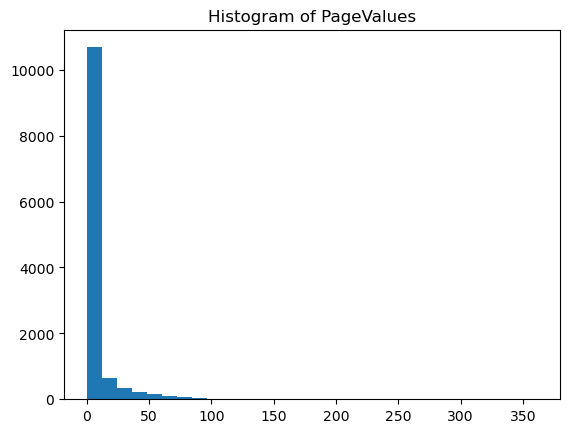

In [104]:
# EDA & Pre-processing - Histogram of Numeric Features - Histogram of PageValues
plt.hist(df[num_cols[8]], bins=30)
plt.title(f'Histogram of {num_cols[8]}')
plt.show()

In [105]:
# EDA & Pre-processing - Distributions - Distribution of the target column
target_col = 'Revenue'
feature_cols = [col for col in dataset.columns if col != target_col]

print(df[target_col].value_counts())

Revenue
False    10422
True      1908
Name: count, dtype: int64


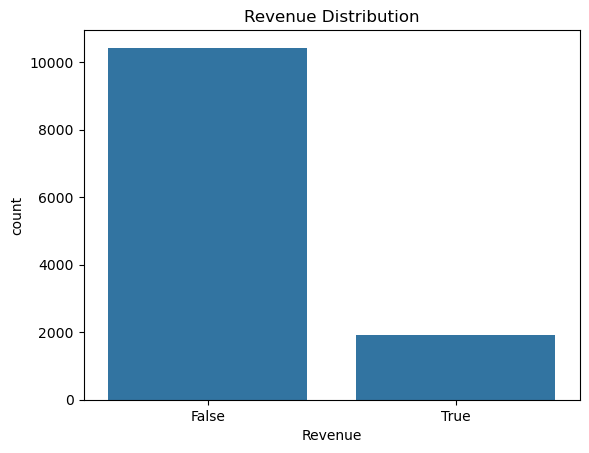

In [106]:
# EDA & Pre-processing - Distributions - Histogram of Revenue distribution
sns.countplot(x=target_col, data=df)
plt.title('Revenue Distribution')
plt.show()

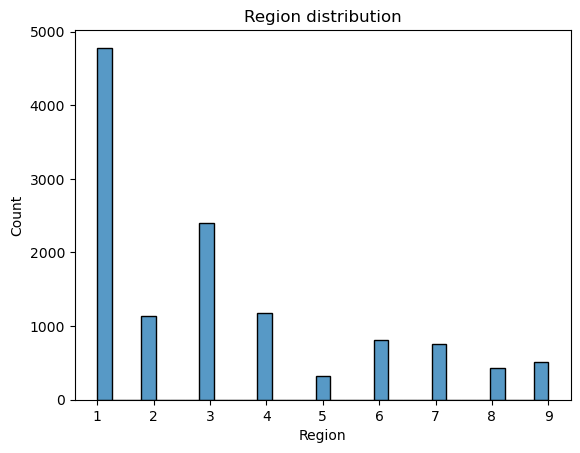

In [107]:
# EDA & Pre-processing - Distributions - Histogram of Region distribution
sns.histplot(df.Region)
plt.title('Region distribution')
plt.show()

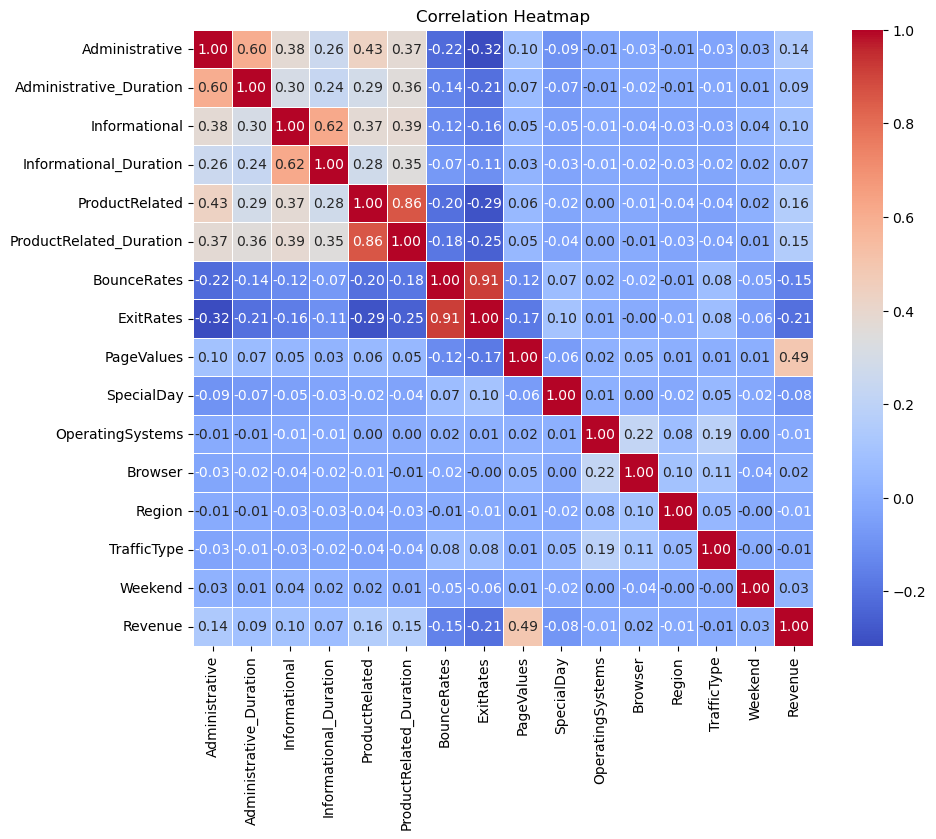

In [108]:
# EDA & Pre-processing - Correlation Heatmap
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

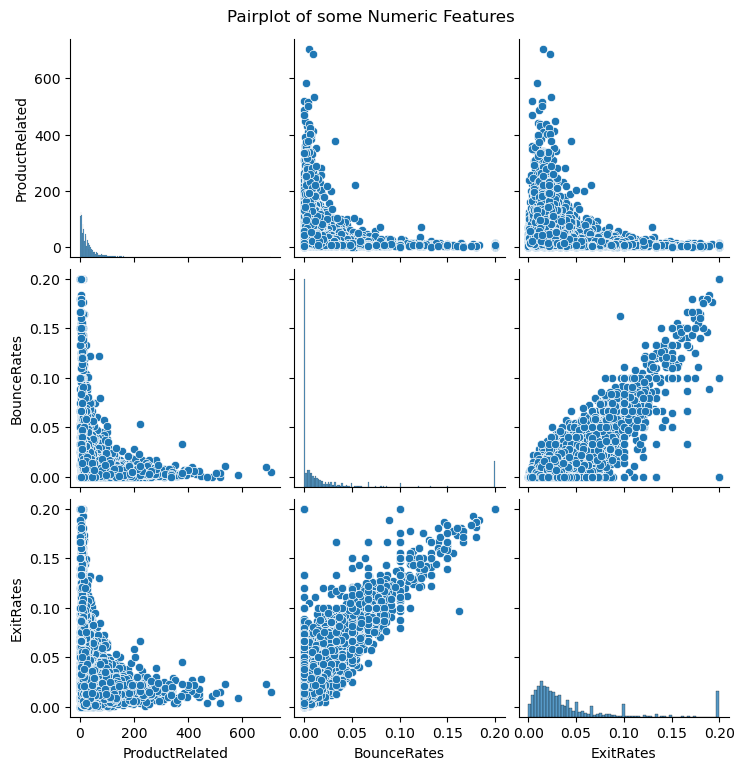

In [109]:
# EDA & Pre-processing - Pairplot of Numeric Features
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'bool'])

sns.pairplot(numeric_cols[['ProductRelated', 'BounceRates', 'ExitRates']])
plt.suptitle('Pairplot of some Numeric Features', y=1.02)
plt.show()

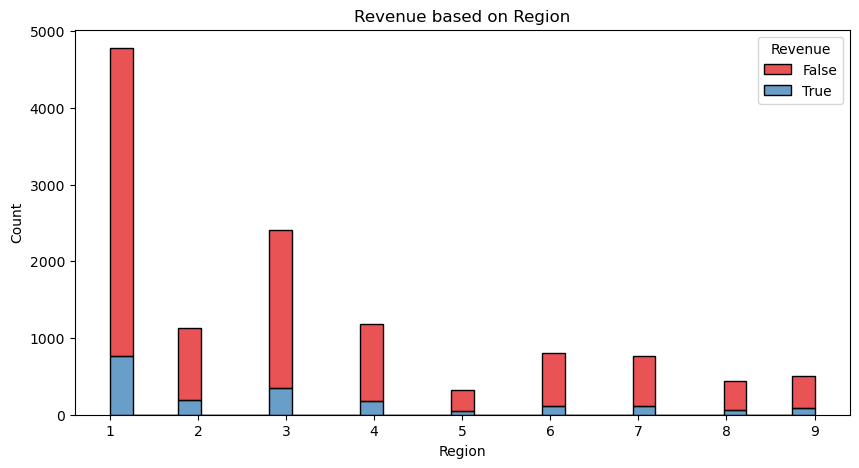

In [110]:
# EDA & Pre-processing - Check revenue based on region and generate histogram 
custom_palette = sns.color_palette("Set1")
plt.figure(figsize=(10, 5))
plt.title("Revenue based on Region")
sns.histplot(x="Region", hue="Revenue", data=df, palette=custom_palette, multiple="stack")
plt.show()

In [111]:
# Splitting Features and Target for Modelling
X = df.drop('Revenue', axis=1) # Drop target column from dataset
y = df['Revenue'] # Set for prediction

In [112]:
# Data splitting into training(80%) and testing(20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [113]:
# Model Building - logistic Regression 
pipe_lr = Pipeline([ # Pipeline for Logistic Regression
    ('scaler', StandardScaler()), # Scaling
    ('clf', LogisticRegression(max_iter=2000, random_state=42)) # Train the model
])

In [114]:
# Model Building - logistic Regression - Organize features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist() # Select numeric columns
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist() # Select categorical columns

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Categorical features: ['Month', 'VisitorType', 'Weekend']


In [115]:
# Model Building - logistic Regression
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Scaling numeric features
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features) # One-hot encoding categorical features
    ]
)

In [116]:
# Model Building - logistic Regression - Pipeline with preprocessing and Logistic Regression classifier
pipe_lr = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

# Fine tune Logistic Regression model using GridSearchCV
param_grid_lr = {'clf__C': [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='f1', cv=5, n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_lr.best_params_)

Best Logistic Regression Params: {'clf__C': 10}


In [117]:
# Model Building - Random Forest - Pipeline with preprocessing and Random Forest classifier
pipe_rf = Pipeline([
    ('preprocess', preprocessor),  # <--- reuse this
    ('clf', RandomForestClassifier(random_state=42))
])

# Fine tune Random Forest model using GridSearchCV
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring='f1', cv=4, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best Random Forest Params:", grid_rf.best_params_)

Best Random Forest Params: {'clf__max_depth': 20, 'clf__n_estimators': 200}


In [118]:
# Evaluate performance of both models

# Predictions and compute probabilities on the test set
def evaluate_model(grid, X_test, y_test, model_name):
    y_pred = grid.predict(X_test) 
    y_proba = grid.predict_proba(X_test)[:, 1]

    # Classification report (Accuracy, Precision, Recall, F1-score)
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))

    # Compute and print the ROC AUC score
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC Score for {model_name}: {auc:.4f}")

    # Confusion matrix using a heatmap
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # ROC curve plotting
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    return y_pred, y_proba

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

       False       0.89      0.98      0.93      2084
        True       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

ROC AUC Score for Logistic Regression: 0.8876


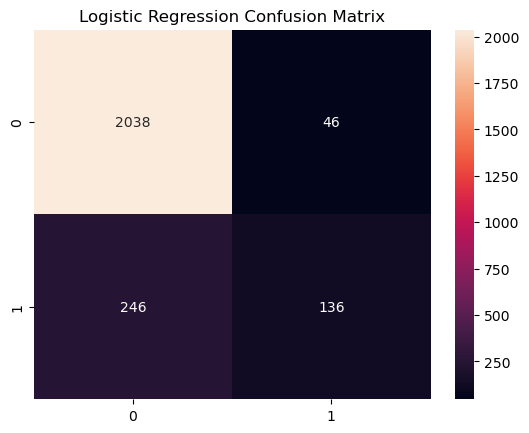

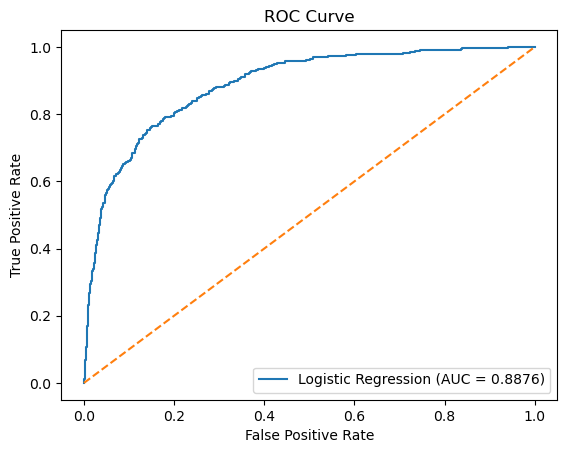

In [119]:
#Logistic Regression - Classification Report - ROC AUC Score - Confusion Matrix Heatmap - ROC Curve
y_pred_lr, y_proba_lr = evaluate_model(grid_lr, X_test, y_test, "Logistic Regression")

Classification Report for Random Forest:

              precision    recall  f1-score   support

       False       0.92      0.96      0.94      2084
        True       0.74      0.54      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.75      0.78      2466
weighted avg       0.89      0.90      0.89      2466

ROC AUC Score for Random Forest: 0.9189


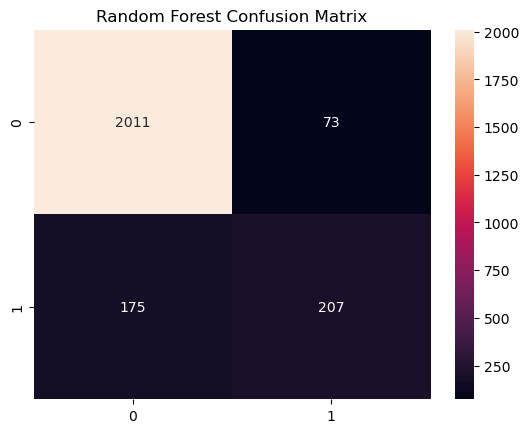

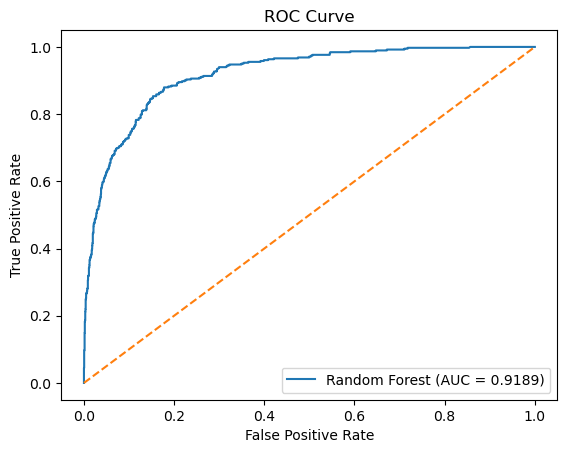

In [120]:
#Random Forest - Classification Report - ROC AUC Score - Confusion Matrix Heatmap - ROC Curve
y_pred_rf, y_proba_rf = evaluate_model(grid_rf, X_test, y_test, "Random Forest")

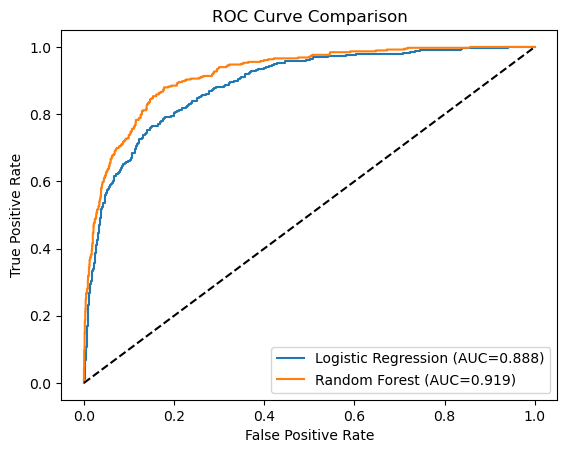

In [121]:
# Calculate False Positive and True Positive rates for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

#Plotting ROC Curve for both Logistic Regression and Random Forest
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test,y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test,y_proba_rf):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

Number of features seen by RF: 26
Length of feature_importances_: 26


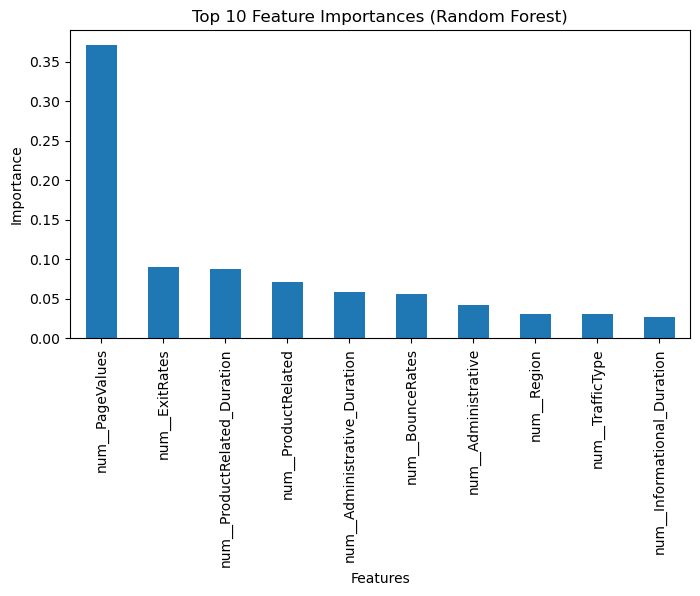

In [122]:
# Retrieve best model from GridSearchCV results
rf_pipeline_best = grid_rf.best_estimator_
rf_best = rf_pipeline_best.named_steps['clf']

preprocessor = rf_pipeline_best.named_steps['preprocess']
feature_names = preprocessor.get_feature_names_out()

# Print number of features and length of feature importances
print("Number of features seen by RF:", len(feature_names))
print("Length of feature_importances_:", len(rf_best.feature_importances_))

# Create pandas series to display feature importances and sort them in descending order
feat_importances = pd.Series(rf_best.feature_importances_, index=feature_names)

# Plot top 10 most important features using bar plot
feat_importances.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(8,4))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [123]:
# Calculate F1 score for both Logistic Regression and Random Forest
f1_lr = f1_score(y_test, y_pred_lr)
f1_rf = f1_score(y_test, y_pred_rf)

# Select best model based on higher F1 score
best_model = grid_rf if f1_rf >= f1_lr else grid_lr

# Save best model using joblib
joblib.dump(best_model.best_estimator_, "best_revenue_classifier.joblib")

print(f"Saved best model: {'Random Forest' if f1_rf >= f1_lr else 'Logistic Regression'} with F1: {max(f1_rf, f1_lr):.4f}")

Saved best model: Random Forest with F1: 0.6254


In [124]:
# Comparison of both models
# Train Logistic Regression model and make predictions
lr_best = grid_lr.best_estimator_
lr_best.fit(X_train, y_train)
y_pred_lr = lr_best.predict(X_test)

# Evaluate Logistic Regression performance
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

# Train Random Forest model and make predictions
rf_best = grid_rf.best_estimator_
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)

# Evaluate Random Forest performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

In [125]:
# Print comparison of models
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

Logistic Regression Performance:
Accuracy: 0.8816
Precision: 0.7473
Recall: 0.3560
F1-Score: 0.4823

Random Forest Performance:
Accuracy: 0.8994
Precision: 0.7393
Recall: 0.5419
F1-Score: 0.6254


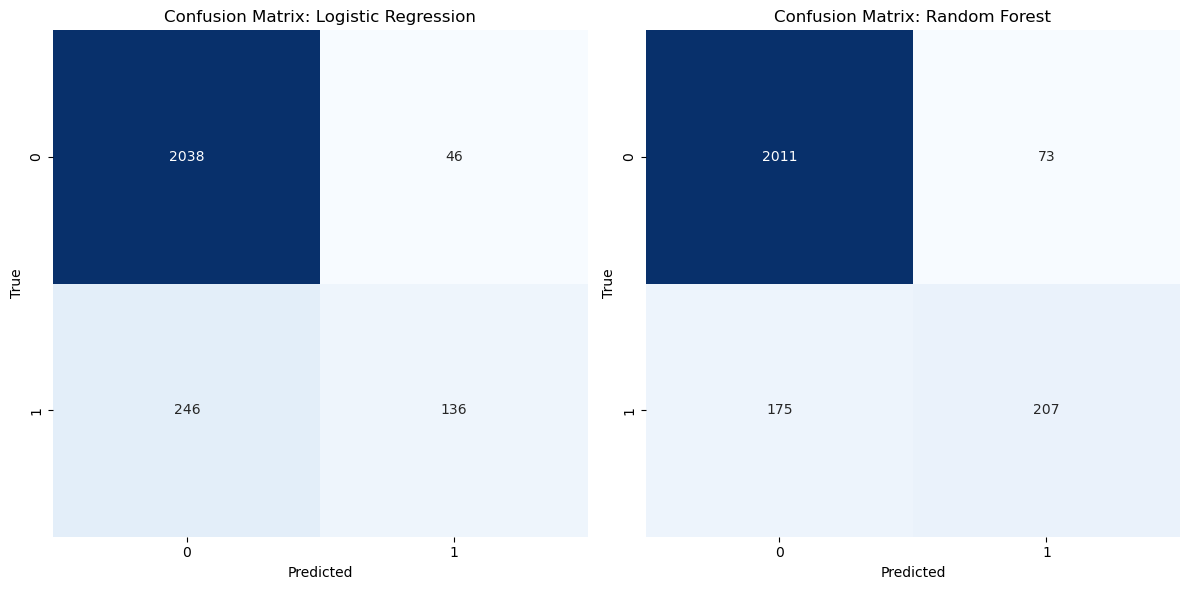

In [126]:
# Confusion Matrices of Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(conf_matrix_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix: Logistic Regression")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix: Random Forest")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()